In [ ]:
# pip install rasterio

In [1]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# Open a GeoTIFF file
try:
    # Nbs = Nature based solutions
    with rasterio.open(r'C:\Users\elchi\Desktop\UIC_Chicago\scout\backend\data\Final_Story_maps\2020_2040_NbS.tif') as src:
        # Read the entire image or specific bands
        image_data = src.read()  # Reads all bands into a 3D NumPy array
        # image_band1 = src.read(1) # Reads only the first band

        print("GeoTIFF data loaded successfully.")
        print(f"Image shape: {image_data.shape}")
        print(f"Coordinate Reference System (CRS): {src.crs}")
        print(f"Bounds: {src.bounds}")
except FileNotFoundError:
    print("Error: The specified GeoTIFF file was not found.")
except Exception as e:
    print(f"An error occurred while reading the GeoTIFF file: {e}")

GeoTIFF data loaded successfully.
Image shape: (1, 5376, 6656)
Coordinate Reference System (CRS): EPSG:26915
Bounds: BoundingBox(left=681109.2856144982, bottom=4574248.375694828, right=743462.7860188653, top=4624610.818329125)


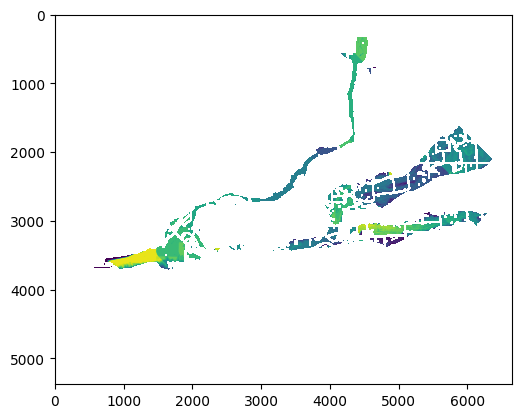

In [2]:
show(image_data, cmap='viridis')
plt.show()

GeoTIFF data loaded successfully.
Image shape: (1, 5376, 6656)
Coordinate Reference System (CRS): EPSG:26915
Bounds: BoundingBox(left=681109.2856144982, bottom=4574248.375694828, right=743462.7860188653, top=4624610.818329125)


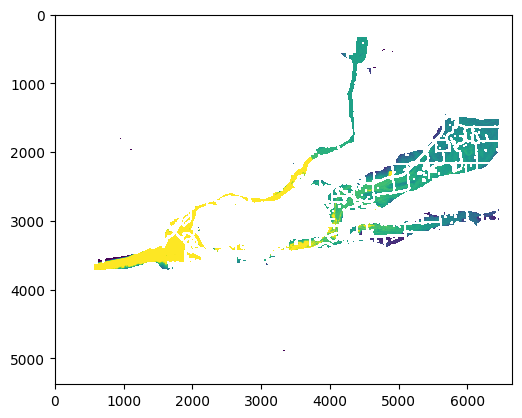

In [11]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# Open a GeoTIFF file
try:
    # Nbs = Nature based solutions
    with rasterio.open(r'C:\Users\elchi\Desktop\UIC_Chicago\scout\backend\data\Final_Story_maps\2020_2040_noNbS.tif') as src:
        # Read the entire image or specific bands
        image_data = src.read()  # Reads all bands into a 3D NumPy array
        # image_band1 = src.read(1) # Reads only the first band

        print("GeoTIFF data loaded successfully.")
        print(f"Image shape: {image_data.shape}")
        print(f"Coordinate Reference System (CRS): {src.crs}")
        print(f"Bounds: {src.bounds}")
except FileNotFoundError:
    print("Error: The specified GeoTIFF file was not found.")
except Exception as e:
    print(f"An error occurred while reading the GeoTIFF file: {e}")
    
show(image_data, cmap='viridis')
plt.show()

GeoTIFF data loaded successfully.
Image shape: (41031, 41956)
Coordinate Reference System (CRS): EPSG:6455
Bounds: BoundingBox(left=300165.8214790943, bottom=1651400.3958731743, right=509945.8214790943, top=1856555.3958731743)


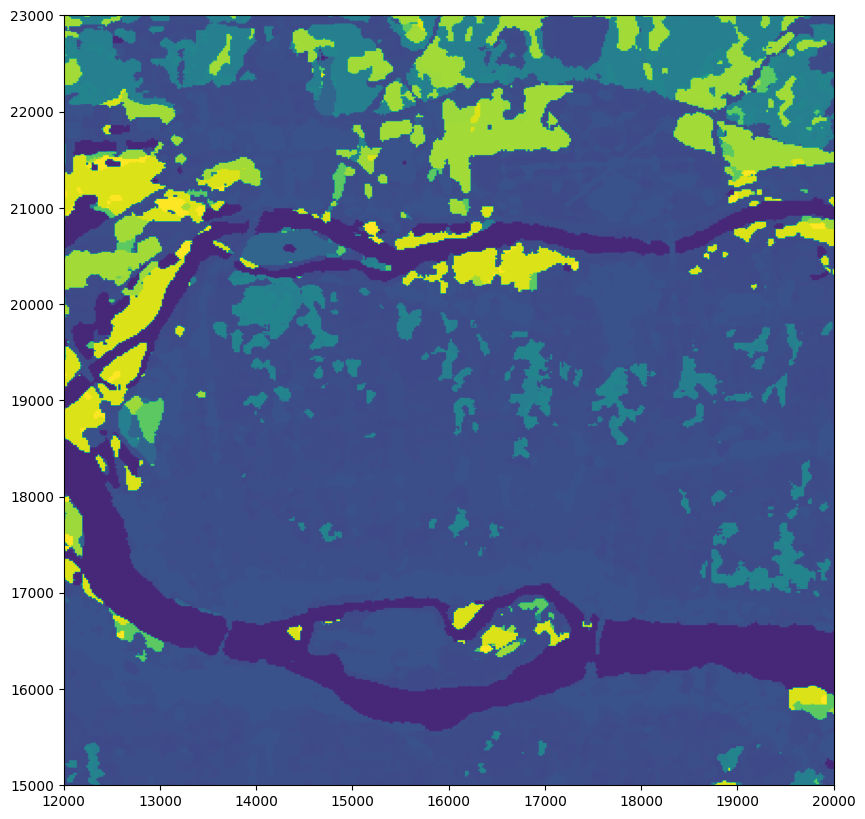

In [ ]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
from rasterio.windows import from_bounds

bounding_box = [ # Flooding data bounding box
    681109.2856144982, 4574248.375694828, 743462.7860188653, 4624610.818329125
]

# Open a GeoTIFF file
try:
    # Nbs = Nature based solutions
    with rasterio.open(r'V:\Datos_CLEETS\NbS_others_5m.tif') as src:
        # Read the entire image or specific bands
        # image_window = src.read(window=window)  # Reads all bands into a 3D NumPy array
        image_band1 = src.read(1) # Reads only the first band

        print("GeoTIFF data loaded successfully.")
        print(f"Image shape: {image_band1.shape}")
        print(f"Coordinate Reference System (CRS): {src.crs}")
        print(f"Bounds: {src.bounds}")
except FileNotFoundError:
    print("Error: The specified GeoTIFF file was not found.")
except Exception as e:
    print(f"An error occurred while reading the GeoTIFF file: {e}")

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_ylim(15000, 23000)
ax.set_xlim(12000, 20000)

ax.imshow(image_band1, cmap='viridis')

plt.show()
# This is upside down

raster bounds: BoundingBox(left=300165.8214790943, bottom=1651400.3958731743, right=509945.8214790943, top=1856555.3958731743)
cropping to bbox: (356806.4214790943, 1747823.2458731744, 411349.2214790943, 1801163.5458731742)
cropped shape: (10668, 10909)


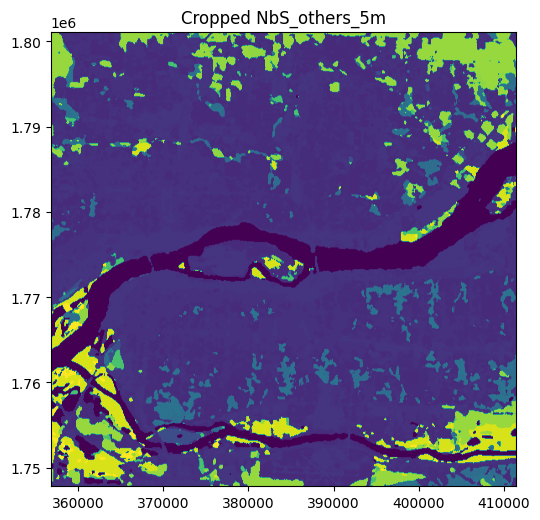

In [ ]:
import rasterio
from rasterio.plot import show
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt

with rasterio.open(r'V:\Datos_CLEETS\NbS_others_5m.tif') as src:
    b = src.bounds
    print("raster bounds:", b)

    # here we define a bbox inside those bounds
    minx = b.left  + 0.27 * (b.right - b.left)
    maxx = b.left  + 0.53 * (b.right - b.left)
    miny = b.bottom + 0.47 * (b.top - b.bottom)
    maxy = b.bottom + 0.73 * (b.top - b.bottom)
    
    print("cropping to bbox:", (minx, miny, maxx, maxy))

    window = from_bounds(minx, miny, maxx, maxy, src.transform)

    cropped = src.read(1, window=window)
    cropped_transform = src.window_transform(window)

print("cropped shape:", cropped.shape)

fig, ax = plt.subplots(figsize=(6, 6))
show(cropped, transform=cropped_transform, cmap='viridis', ax=ax)
ax.set_title("Cropped NbS_others_5m")
plt.show()

c:\Users\elchi\Desktop\UIC_Chicago\scout\backend\envs\lib\site-packages\rasterio\__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


GeoTIFF data loaded successfully.
Image shape: (1, 41031, 41956)
Coordinate Reference System (CRS): None
Bounds: BoundingBox(left=0.0, bottom=41031.0, right=41956.0, top=0.0)


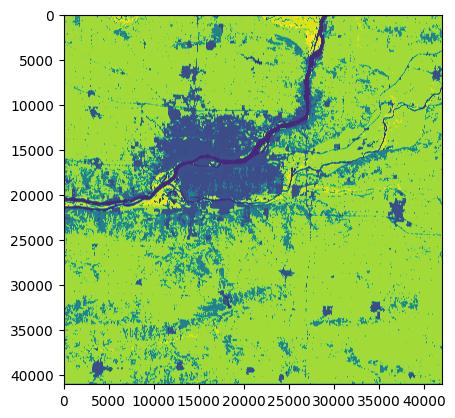

In [ ]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

try:
    with rasterio.open("cropped.tif") as src:
        image_data = src.read()  # Reads all bands into a 3D NumPy array


        print("GeoTIFF data loaded successfully.")
        print(f"Image shape: {image_data.shape}")
        print(f"Coordinate Reference System (CRS): {src.crs}")
        print(f"Bounds: {src.bounds}")
except FileNotFoundError:
    print("Error: The specified GeoTIFF file was not found.")
except Exception as e:
    print(f"An error occurred while reading the GeoTIFF file: {e}")
    
show(image_data, cmap='viridis')
plt.show()

In [ ]:
import tifffile
with tifffile.TiffFile(r'V:\Datos_CLEETS\NbS_others_5m.tif') as tif:
    tif_tags = {}
    for tag in tif.pages[0].tags.values():
        name, value = tag.name, tag.value
        tif_tags[name] = value
    image = tif.pages[0].asarray()
    print(tif_tags)

In [ ]:
import rasterio
import numpy as np

with rasterio.open(r'V:\Datos_CLEETS\NbS_others_5m.tif') as src:
    band1 = src.read(1)
    print(src.meta)
    print(src.tags())
    print(src.tags(1))

print("nodata:", src.nodata)

print("Shape:", band1.shape)
print("Min:", np.nanmin(band1), "Max:", np.nanmax(band1))

unique_values = np.unique(band1)
print("Unique values:", unique_values) # In theory, these correspond to different NbS classes

# val = band1[100, 200]
# print("Value at (100, 200):", val)

{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 0.0, 'width': 41956, 'height': 41031, 'count': 1, 'crs': CRS.from_epsg(6455), 'transform': Affine(5.0, 0.0, 300165.8214790943,
       0.0, -5.0, 1856555.3958731743)}
{'AREA_OR_POINT': 'Area', 'DataType': 'Thematic'}
{'RepresentationType': 'THEMATIC'}
nodata: 0.0
Shape: (41031, 41956)
Min: 0 Max: 95
Unique values: [ 0 11 21 22 23 24 31 41 42 43 52 71 81 82 90 95]
Value at (100, 200): 82
